(12)=
# Chapter 12: Polynomial Fitting 

**Topics Covered:**
- Polynomial basics: `np.poly1d`, `np.polyval`, `np.polyfit`
- Least-squares polynomial fitting: choosing the right degree, residuals, $R^2$

> ### 📋 Instructor Note — Introduction
> 
> Good [morning/afternoon] everyone. Today we're in Chapter 12 — **Polynomial Fitting and Interpolation**. This is one of the most practically useful chapters in the course because these techniques come up constantly in real engineering work.
> 
> A polynomial is one of the most fundamental objects in mathematics, especially in algebra, calculus, and engineering models. A polynomial is an expression made of variables (like x), coefficients (numbers), exponents that are non-negative integers, and addition, subtraction, and multiplication only.
> 
> The big picture: experimental data and published tables always give you numbers at *specific* conditions. But in design calculations, you almost never need the function at *exactly* those conditions — you need it at some arbitrary intermediate point, or you need to integrate it, or differentiate it. Polynomials let you convert discrete data into a continuous mathematical model you can do calculus on.
> 
> By the end of today you'll know how to:
> - Fit a polynomial to noisy data and evaluate it at any point
> - Use Taylor series to linearize nonlinear functions like Arrhenius
> - Interpolate through tabulated data without introducing artifacts
> - Apply all of this to real ChE problems — heat capacity, steam tables, reaction kinetics

In [5]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

(12.1)=
## 12.1 Motivation: Heat Capacity of CO$_2$

In chemical engineering, we frequently need $C_p(T)$ — the molar heat capacity as a function of temperature — to compute:

$$
Q = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

NIST publishes $C_p$ in tabulated form at discrete temperatures. Before we can integrate, we need a **continuous mathematical model** — a polynomial — that passes smoothly through the data.

Below is a subset of NIST data for CO$_2$ (ideal gas, J mol$^{-1}$ K$^{-1}$):

| $T$ (K) | $C_p$ (J mol$^{-1}$ K$^{-1}$) |
|---------|-------------------------------|
| 300     | 37.13                         |
| 400     | 41.33                         |
| 500     | 44.60                         |
| 600     | 47.33                         |
| 700     | 49.65                         |
| 800     | 51.61                         |
| 900     | 53.26                         |
| 1000    | 54.31                         |
| 1100    | 55.37                         |
| 1200    | 56.21                         |

We want to fit $C_p(T) \approx a_0 + a_1 T + a_2 T^2 + \cdots$ so we can evaluate it at any temperature and integrate it analytically.

> ### 📋 Instructor Note — 12.1
> 
> Here's the problem. NIST publishes molar heat capacity data for CO₂ at discrete temperatures — 300 K, 400 K, 500 K, up to 1200 K. Ten data points total.
> 
> Now suppose you're designing a heat exchanger and need:
> 
> $$Q = n \int_{400}^{900} C_p(T)\, dT$$
> 
> You **cannot** integrate a table of numbers directly — you need a *function*. That's what polynomial fitting gives you.
> 
> *(Run the plot cell — show the data points)*
> 
> Notice the trend: $C_p$ increases with temperature and starts leveling off. It's clearly not linear, but it's smooth and monotonic — a classic candidate for a low-degree polynomial fit.

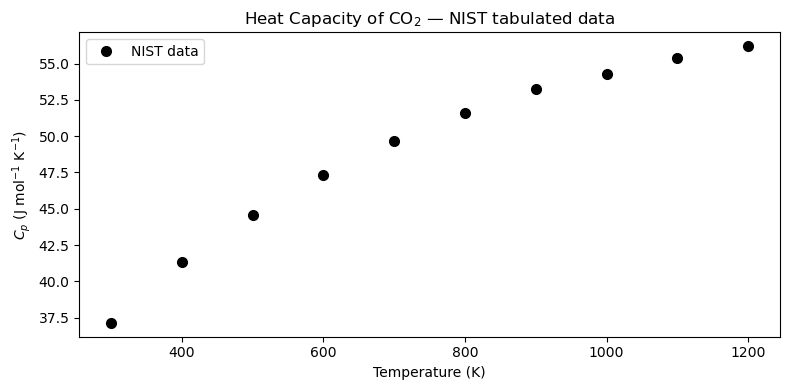

In [6]:
# NIST tabulated Cp data for CO2 (ideal gas)
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

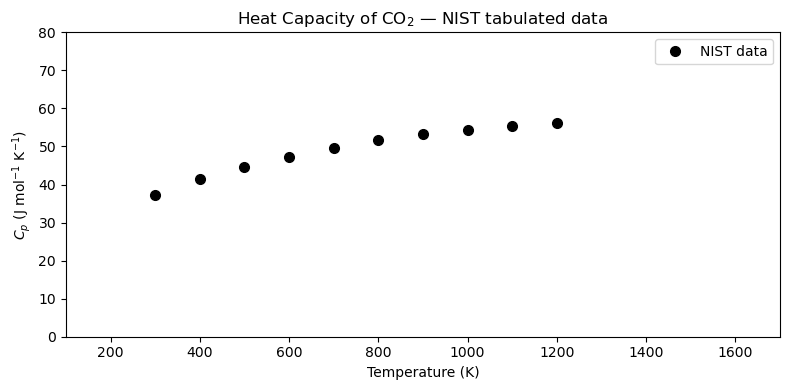

In [7]:
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.set_xlim(100, 1700)
ax.set_ylim(0, 80)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

(12.2)=
## 12.2 Polynomial Basics

A degree-$n$ polynomial is:

$$
p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0
$$

NumPy stores polynomial coefficients in **descending order** (highest power first). Three key tools:

| Function | Purpose |
|----------|---------|
| `np.poly1d(coeffs)` | Create a callable polynomial object |
| `np.polyval(coeffs, x)` | Evaluate polynomial at $x$ |
| `np.polyfit(x, y, deg)` | Least-squares fit: returns coefficients |

**Convention:** `coeffs = [a_n, a_{n-1}, ..., a_1, a_0]` — highest power first.

---

### The coefficient array

Say you have $p(x) = 3x^2 + 5x - 2$. NumPy represents this as `[3, 5, -2]`:

```
index:  0    1    2
value: [3,   5,  -2]
         ↑    ↑    ↑
        x²   x¹   x⁰
```

### `np.poly1d(coeffs)` — callable polynomial object

Wraps the coefficient list into an object you can call like a function:
```python
p = np.poly1d([3, 5, -2])
p(1)   # → 3(1)² + 5(1) - 2 = 6
p(0)   # → -2
```
Bonus methods: `p.deriv()` (derivative), `p.integ()` (integral), `p.roots` (zeros).

### `np.polyval(coeffs, x)` — evaluate from the list directly

Same result, no object needed. Works on scalars or arrays:
```python
np.polyval([3, 5, -2], 1)           # → 6
np.polyval([3, 5, -2], [0, 1, 2])   # → [-2, 6, 20]
```
Use this when you only need values and don't need derivatives/integrals.

### `np.polyfit(x, y, deg)` — find best-fit coefficients

Given data points, returns a coefficient array in the same descending convention:
```python
coeffs = np.polyfit(x_data, y_data, deg=3)  # fit  → coeffs
p      = np.poly1d(coeffs)                  # wrap → callable
y_fit  = p(x_fine)                          # evaluate on dense grid
# or equivalently:
y_fit  = np.polyval(coeffs, x_fine)
```

Use `poly1d` when you also need `.deriv()` / `.integ()` / `.roots`; use `polyval` when you just need numbers.

> ### 📋 Instructor Note — 12.2
> 
> Before we fit anything, let's nail down the three NumPy tools you'll use for every polynomial calculation in this course.
> 
> **The coefficient convention** — this is where people get tripped up.
> 
> NumPy stores coefficients in *descending* power order. For $p(x) = 3x^2 + 5x - 2$, NumPy wants `[3, 5, -2]`. Index 0 = highest power, last index = constant. **Highest power first.**
> 
> **`np.poly1d(coeffs)`** wraps a list into a callable object. Its bonus: `.deriv()`, `.integ()`, `.roots`. Use it when you need calculus operations.
> 
> **`np.polyval(coeffs, x)`** evaluates directly from a list — works on scalars or arrays. Use it when you just need numbers.
> 
> **`np.polyfit(x, y, deg)`** — the workhorse. Give it data and a degree, it returns best-fit coefficients in that same descending convention.
> 
> *(Run the demo cell — point out the pretty-printed poly1d output, the evaluation table showing all three methods agree, then the derivative `6x + 5`, the antiderivative, and the roots)*
> 
> The fact that all three methods — `poly1d`, `polyval`, and manual — give identical results is a good sanity check to run whenever you're unsure.

In [8]:
# ── Coefficient convention demo ───────────────────────────────────────────
# p(x) = 3x² + 5x - 2   →   coeffs = [3, 5, -2]  (descending order)
coeffs_demo = [3, 5, -2]

p_demo = np.poly1d(coeffs_demo)
print("poly1d pretty-print:")
print(p_demo)

# Evaluate at a few points
xs = [0, 1, 2]
print("\nx   poly1d   polyval   manual")
for x in xs:
    manual = 3*x**2 + 5*x - 2
    print(f"{x}   {p_demo(x):6.1f}   {np.polyval(coeffs_demo, x):6.1f}   {manual:6.1f}")

# polyval works on arrays too
print("\npolyval on array [0,1,2]:", np.polyval(coeffs_demo, xs))

# Derivative and integral via poly1d
print("\nDerivative p'(x):")
print(p_demo.deriv())
print("Indefinite integral ∫p dx (+ C):")
print(p_demo.integ())
print("Roots (p(x)=0):", p_demo.roots.round(4))


poly1d pretty-print:
   2
3 x + 5 x - 2

x   poly1d   polyval   manual
0     -2.0     -2.0     -2.0
1      6.0      6.0      6.0
2     20.0     20.0     20.0

polyval on array [0,1,2]: [-2  6 20]

Derivative p'(x):
 
6 x + 5
Indefinite integral ∫p dx (+ C):
   3       2
1 x + 2.5 x - 2 x
Roots (p(x)=0): [-2.      0.3333]


In [9]:
# Define p(x) = 2x^3 - 3x^2 + x - 5  (coefficients in descending order)
coeffs = [2, -3, 1, -5]

p = np.poly1d(coeffs)
print("Polynomial p(x):")
print(p)

# Evaluate at x = 2
x_val = 2.0
print(f"\np({x_val}) using poly1d  : {p(x_val):.4f}")
print(f"p({x_val}) using polyval : {np.polyval(coeffs, x_val):.4f}")
# Manual: 2(8) - 3(4) + 1(2) - 5 = 16 - 12 + 2 - 5 = 1
print(f"Manual check          : {2*x_val**3 - 3*x_val**2 + 1*x_val - 5:.4f}")

Polynomial p(x):
   3     2
2 x - 3 x + 1 x - 5

p(2.0) using poly1d  : 1.0000
p(2.0) using polyval : 1.0000
Manual check          : 1.0000


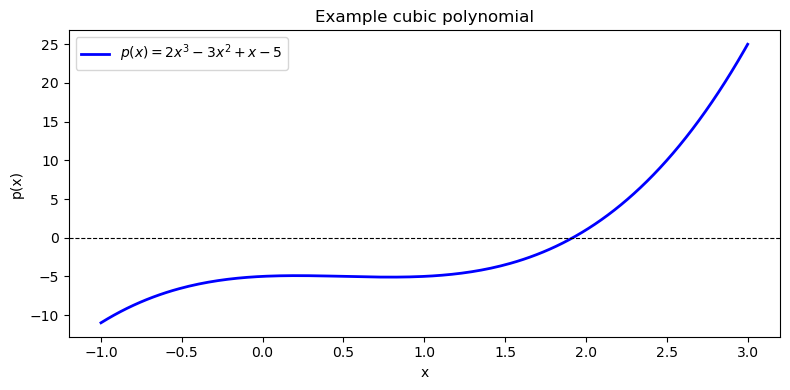

In [10]:
# Plot the polynomial over [-1, 3]
x = np.linspace(-1, 3, 200)
y = np.polyval(coeffs, x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, 'b-', linewidth=2, label=r'$p(x) = 2x^3 - 3x^2 + x - 5$')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Example cubic polynomial')
ax.legend()
plt.tight_layout()
plt.show()

(12.3)=
## 12.3 Least-Squares Polynomial Fitting

**`np.polyfit(x, y, deg)`** finds the degree-`deg` polynomial coefficients that minimize the sum of squared residuals:

$$
\min_{a_0, \ldots, a_n} \sum_{i=1}^{N} \left[ y_i - p(x_i) \right]^2
$$

This is ordinary least squares applied to a polynomial basis. The function returns coefficients in descending order (highest power first), just like `np.poly1d` expects.

> ### 📋 Instructor Note — 12.3
> 
> `np.polyfit` solves a least-squares problem:
> 
> $$\min_{a_0,\ldots,a_n} \sum_{i=1}^{N} [y_i - p(x_i)]^2$$
> 
> This is ordinary least squares applied to a polynomial basis. NumPy sets up the Vandermonde matrix and does the linear algebra internally — you just specify the degree.

(12.3.1)=
### 12.3.1 Fitting Cp(T) with Different Degrees

We fit the CO$_2$ data with degree 1, 2, and 3 polynomials and compare the results visually.

> ### 📋 Instructor Note — 12.3.1
> 
> *(Run the plot cell — three curves: linear (red), quadratic (orange), cubic (blue) over the NIST data)*
> 
> The **linear fit** clearly doesn't capture the curvature — it underestimates in the middle and is off at both ends. The **quadratic** is much better. The **cubic** hugs the data very tightly.
> 
> But 'looks good visually' isn't enough — we need numbers.

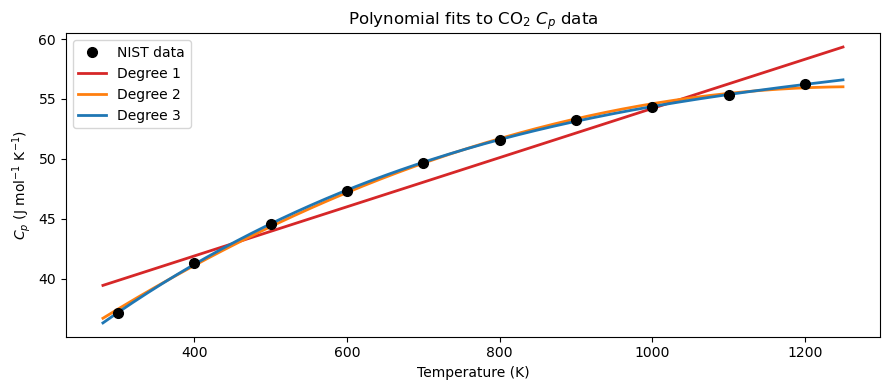

In [11]:
# ── Fit Cp(T) with degree 1, 2, 3 polynomials ────────────────────────────────
T_fine = np.linspace(280, 1250, 300)

# Fit each degree separately
coeffs_deg1 = np.polyfit(T_data, Cp_data, 1)
coeffs_deg2 = np.polyfit(T_data, Cp_data, 2)
coeffs_deg3 = np.polyfit(T_data, Cp_data, 3)

# Evaluate each fit on the fine grid
Cp_deg1 = np.polyval(coeffs_deg1, T_fine)
Cp_deg2 = np.polyval(coeffs_deg2, T_fine)
Cp_deg3 = np.polyval(coeffs_deg3, T_fine)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
ax.plot(T_fine, Cp_deg1, color='tab:red',    linewidth=2, label='Degree 1')
ax.plot(T_fine, Cp_deg2, color='tab:orange', linewidth=2, label='Degree 2')
ax.plot(T_fine, Cp_deg3, color='tab:blue',   linewidth=2, label='Degree 3')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Polynomial fits to CO$_2$ $C_p$ data')
ax.legend()
plt.tight_layout()
plt.show()

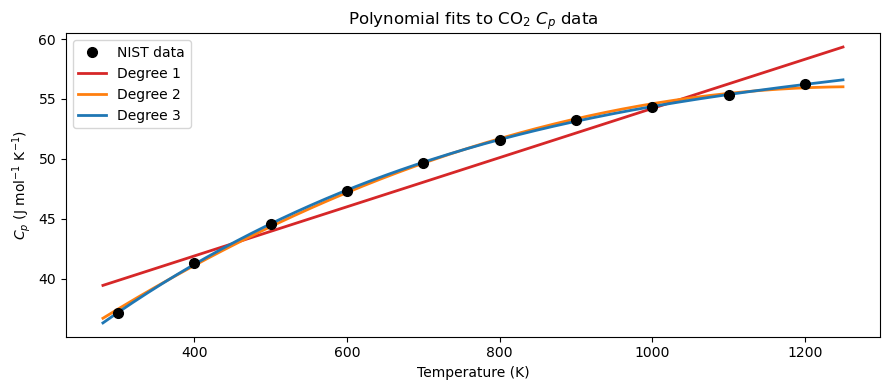

In [12]:
# ── Fit Cp(T) with degree 1, 2, 3 polynomials ────────────────────────────────
T_fine  = np.linspace(280, 1250, 300)
degrees = [1, 2, 3]
colors  = ['tab:red', 'tab:orange', 'tab:blue']
fits    = {}    # store coefficient arrays keyed by degree

for deg in degrees:
    fits[deg] = np.polyfit(T_data, Cp_data, deg)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
for deg, color in zip(degrees, colors):
    ax.plot(T_fine, np.polyval(fits[deg], T_fine),
            color=color, linewidth=2, label=f'Degree {deg}')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Polynomial fits to CO$_2$ $C_p$ data')
ax.legend()
plt.tight_layout()
plt.show()

The residual $e_i$ is the vertical distance between a measured data point and the model's prediction at that same $x$:

$$
e_i = y_i - p(x_i)
$$

A positive residual means the model underpredicts; negative means it overpredicts. A good fit has residuals that are small and scattered randomly around zero.

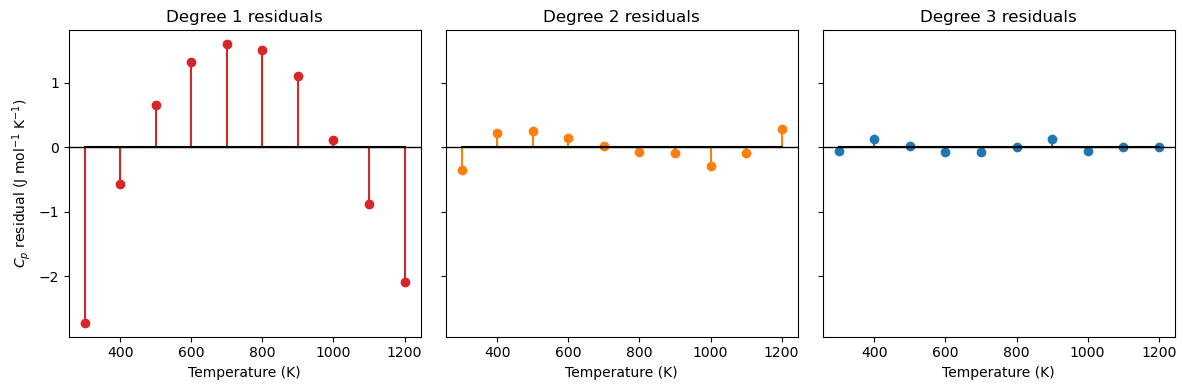

In [13]:
# ── Residual stem plots for each degree ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, deg, color in zip(axes, degrees, colors):
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    ax.stem(T_data, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'Degree {deg} residuals')

axes[0].set_ylabel(r'$C_p$ residual (J mol$^{-1}$ K$^{-1}$)')
plt.tight_layout()
plt.show()

(12.3.2)=
### 12.3.2 Fit Quality Metrics: MAE, MSE, and $R^2$

Given residuals $e_i = y_i - p(x_i)$, where:
- $y_i$ — observed (measured) value at point $i$
- $p(x_i)$ — model-predicted value at the same point $x_i$

three standard metrics quantify how well the model fits the data:

$$
\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |e_i|
\qquad
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} e_i^2
\qquad
R^2 = 1 - \frac{\sum_i e_i^2}{\sum_i (y_i - \bar{y})^2}
$$

| Metric | Full name | Units | Interpretation |
|--------|-----------|-------|----------------|
| **MAE** | Mean Absolute Error | same as $y$ | Average magnitude of error; easy to interpret |
| **MSE** | Mean Squared Error | $y^2$ | Penalizes large errors more heavily; used by least-squares optimization |
| **$R^2$** | Coefficient of Determination | dimensionless | Fraction of variance explained by the model; 1 = perfect |

**Why square in MSE (and not just use MAE)?**
- **Penalize large errors more heavily** — an error of 2 contributes 4× more than an error of 1; the fit is driven by the worst offenders
- **Smooth, differentiable objective** — $e_i^2$ has a clean derivative everywhere, which is what allows least-squares to be solved analytically; $|e_i|$ is not differentiable at zero

**Interpreting $R^2$:** Here $\bar{y} = \frac{1}{N}\sum_i y_i$ is the mean of all measured values — the "dumbest possible prediction" (just guess the average every time). The denominator $\sum_i(y_i - \bar{y})^2$ is how much the data varies around that mean (total spread). The numerator $\sum_i e_i^2$ is the variance your model *failed* to explain. Subtracting their ratio from 1 gives the fraction the model *does* explain. If the model only predicted $\bar{y}$ for every point, $R^2 = 0$; a perfect fit gives $R^2 = 1$.

- $R^2 = 1$ — perfect fit; every residual is zero
- $R^2 = 0$ — the model does no better than predicting $\bar{y}$ for every point
- $R^2 < 0$ — the model is worse than the mean (a sign something is seriously wrong)

True values:      [1 2 3]
Predicted values: [2. 2. 2.]
Residuals (true - pred): [-1.  0.  1.]
Variance of residuals (model error): 1.0
Variance of true values (data variability): 1.0
R² (coefficient of determination): 0.0


Text(0.5, 1.0, 'Parity plot')

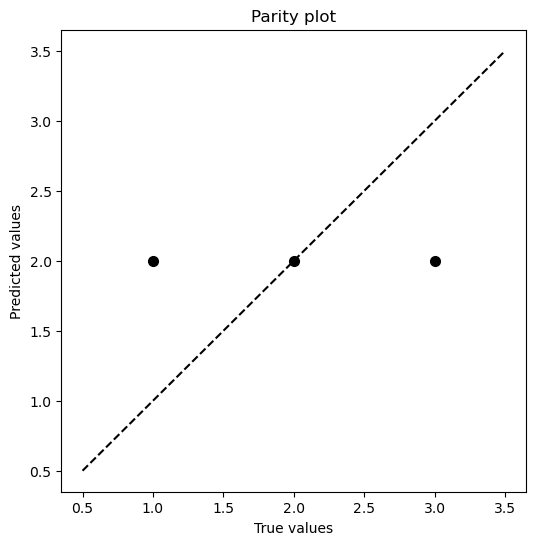

In [14]:
true = np.array([1, 2, 3])
mean = np.mean(true)
pred = np.array([1.1, 1.7, 3.2]) 
pred = np.array([mean, mean, mean])
residuals = true - pred
print("True values:     ", true)
print("Predicted values:", pred)
print("Residuals (true - pred):", residuals)




# numerator = variance of residuals (model error)
residual_variance = np.var(residuals, ddof=1)
print("Variance of residuals (model error):", residual_variance)

# denominator = variance of true values (data variability)
true_variance = np.var(true, ddof=1)
print("Variance of true values (data variability):", true_variance)


# caculate R2
R2 = 1 - residual_variance / true_variance
print("R² (coefficient of determination):", R2)

# plot the parity plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(true, pred, 'ko', markersize=7)
ax.plot([0.5, 3.5], [0.5, 3.5], 'k--')  # parity line
ax.set_xlabel('True values')
ax.set_ylabel('Predicted values')
ax.set_title('Parity plot')

In [12]:
# ── Three-point worked example: compute MAE, MSE, R² by hand ─────────────────
import numpy as np

# Suppose you fit a line to 3 data points and got these predictions:
y_obs  = np.array([2.0, 5.0, 10.0])   # measured values
y_pred = np.array([3.0, 4.0,  9.0])   # model predictions

# Step 1: residuals
e = y_obs - y_pred
print("Residuals e_i:", e)

# Step 2: MAE
MAE = np.mean(np.abs(e))
print(f"\nMAE = mean(|e_i|) = ({' + '.join(f'|{ei:.0f}|' for ei in e)}) / 3 = {MAE:.4f}")

# Step 3: MSE
MSE = np.mean(e**2)
print(f"MSE = mean(e_i^2) = ({' + '.join(f'{ei:.0f}^2' for ei in e)}) / 3 = {MSE:.4f}")

# Step 4: R²
y_bar  = np.mean(y_obs)
SS_res = np.sum(e**2)
SS_tot = np.sum((y_obs - y_bar)**2)
R2     = 1 - SS_res / SS_tot
print(f"\ny_bar = {y_bar:.4f}")
print(f"SS_res = sum(e_i^2)          = {SS_res:.4f}")
print(f"SS_tot = sum((y_i - y_bar)^2) = {SS_tot:.4f}")
print(f"R² = 1 - {SS_res:.4f}/{SS_tot:.4f} = {R2:.4f}")


Residuals e_i: [-1.  1.  1.]

MAE = mean(|e_i|) = (|-1| + |1| + |1|) / 3 = 1.0000
MSE = mean(e_i^2) = (-1^2 + 1^2 + 1^2) / 3 = 1.0000

y_bar = 5.6667
SS_res = sum(e_i^2)          = 3.0000
SS_tot = sum((y_i - y_bar)^2) = 32.6667
R² = 1 - 3.0000/32.6667 = 0.9082


In [22]:
import numpy as np

# ── MAE vs MSE: sensitivity to large errors ──────────────────────────────────
# Two models, same number of points, same MAE — but very different MSE.
#
# Model A: errors are small and uniform
# Model B: errors are mostly tiny, but one is very large (an outlier)

e_A = np.array([1.0,  1.0,  1.0,  1.0,  1.0,  1.0])   # all errors = 1
e_B = np.array([0.1,  0.1,  0.1,  0.1,  0.1,  5.5])   # one large outlier

print(f"{'':8}  {'MAE':>8}  {'MSE':>8}")
print("-" * 28)
for label, e in [('Model A', e_A), ('Model B', e_B)]:
    mae = np.mean(np.abs(e))
    mse = np.mean(e**2)
    print(f"{label:8}  {mae:>8.4f}  {mse:>8.4f}")

print()
print("Model A errors:", e_A)
print("Model B errors:", e_B)
print()
print("MAE treats every error equally — |5.5| counts the same as five |1|s (by magnitude).")
print("MSE squares it: 5.5^2 = 30.25 vs 1^2 = 1.  The outlier dominates MSE.")


               MAE       MSE
----------------------------
Model A     1.0000    1.0000
Model B     1.0000    5.0500

Model A errors: [1. 1. 1. 1. 1. 1.]
Model B errors: [0.1 0.1 0.1 0.1 0.1 5.5]

MAE treats every error equally — |5.5| counts the same as five |1|s (by magnitude).
MSE squares it: 5.5^2 = 30.25 vs 1^2 = 1.  The outlier dominates MSE.


> ### 📋 Instructor Note — 12.3.2
> 
> *(Run the metrics table cell — show the printed table)*
> 
> Going from degree 1 to 2 cuts the MAE by a factor of 7. Degree 2 to 3 is another factor of 3. At degree 3 we're down to 0.05 J/(mol·K) — excellent for engineering purposes.
> 
> MAE gives you error in physical units — easy to interpret. MSE penalizes large errors more heavily (that's why least-squares works the way it does). R² tells you what fraction of variance the model explains — 1 = perfect.
> 
> *(Run the residuals stem-plot cell — three panels)*
> 
> Now look at the residual *patterns*. The linear residuals curve systematically — the model structure is wrong. The quadratic residuals are smaller but still show a faint pattern. The cubic residuals look like **random scatter around zero** — no systematic trend. That's the hallmark of a well-specified model: the residuals contain no remaining structure.

In [10]:
import numpy as np
# ── MAE, MSE, R² for each polynomial degree ──────────────────────────────────
SS_tot = np.sum((Cp_data - np.mean(Cp_data))**2)

print(f"{'Degree':>6}  {'MAE':>18}  {'MSE':>18}  {'R²':>10}")
print(f"{'':>6}  {'(J/mol/K)':>18}  {'(J/mol/K)²':>18}  {'':>10}")
print("-" * 60)
for deg in degrees:
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    MAE = np.mean(np.abs(residuals))
    MSE = np.mean(residuals**2)
    R2  = 1.0 - np.sum(residuals**2) / SS_tot
    print(f"{deg:>6}  {MAE:>18.6f}  {MSE:>18.6f}  {R2:>10.6f}")

Degree                 MAE                 MSE          R²
                 (J/mol/K)          (J/mol/K)²            
------------------------------------------------------------
     1            1.256000            2.114124    0.942543
     2            0.179212            0.043519    0.998817
     3            0.052923            0.004851    0.999868


(12.3.3)=
### 12.3.3 MAE vs $R^2$: They Can Disagree

MAE and $R^2$ measure different things, so a model can score well on one and poorly on the other.

**Case A — Low MAE, low $R^2$:**
All errors are small in absolute magnitude, but the data has almost no variance. The model barely outperforms the flat mean, so $R^2$ stays near zero even though MAE looks fine.

**Case B — High MAE, high $R^2$:**
The data has a huge range (high variance). Errors are large in absolute units, giving a high MAE — but the model tracks the trend so well that $R^2$ is still close to 1.

The takeaway: **always report both**. MAE tells you the error in physical units (is it acceptable for your application?); $R^2$ tells you whether the model captures the structure of the data.

> ### 📋 Instructor Note — 12.3.3 (MAE vs R²)
> 
> *(Run the two-case plot cell)*
> 
> Case A: all the errors are tiny — MAE looks great. But the data barely varies (range ≈ 0.1), so even a model that predicts the wrong constant value gets an R² near zero. The model explains almost none of the (admittedly tiny) variance.
> 
> Case B: the data spans 0–10,000. A linear fit tracks the trend beautifully (R² ≈ 1), but the scatter is ±50 units — so MAE is large in absolute terms.
> 
> **Takeaway: always report both.** MAE answers "is the error acceptable for my application?" R² answers "does the model capture the structure of the data?" They measure different things.

Case A — Low MAE, Low R²
  Data range : 9.952 – 10.046  (spread ≈ 0.094)
  MAE = 0.0918    MSE = 0.009197    R² = -11.0804

Case B — High MAE, High R²
  Data range : 47.9 – 10018.2  (spread ≈ 9970.3)
  MAE = 21.6016    MSE = 721.01    R² = 0.9999


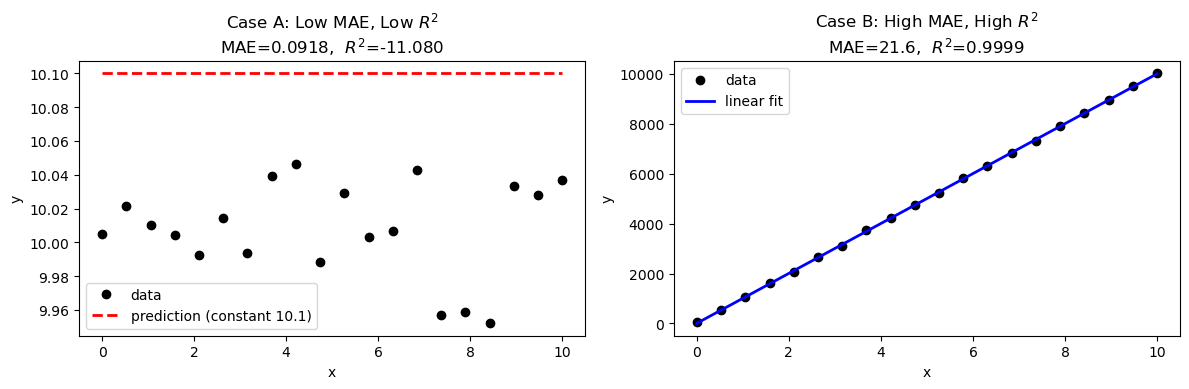

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def metrics(y, y_pred):
    e    = y - y_pred
    mae  = np.mean(np.abs(e))
    mse  = np.mean(e**2)
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2   = 1 - ss_res / ss_tot
    return mae, mse, r2

# ── Case A: Low MAE, Low R² ───────────────────────────────────────────────────
# Data clusters tightly around 10.0 (very low variance).
# The model predicts a constant 10.1 — errors are tiny, but so is the spread,
# so R² is low because the model barely beats the mean.
np.random.seed(0)
x_A  = np.linspace(0, 10, 20)
y_A  = 10.0 + np.random.uniform(-0.05, 0.05, 20)   # near-flat data, range ≈ 0.1
yp_A = np.full_like(y_A, 10.1)                     # constant prediction slightly off

mae_A, mse_A, r2_A = metrics(y_A, yp_A)
print("Case A — Low MAE, Low R²")
print(f"  Data range : {y_A.min():.3f} – {y_A.max():.3f}  (spread ≈ {y_A.max()-y_A.min():.3f})")
print(f"  MAE = {mae_A:.4f}    MSE = {mse_A:.6f}    R² = {r2_A:.4f}")

# ── Case B: High MAE, High R² ─────────────────────────────────────────────────
# Data spans 0–10 000 (huge variance) with a clean linear trend.
# A linear fit tracks it perfectly (R² ≈ 1), but residuals are ~50 units → high MAE.
x_B  = np.linspace(0, 10, 20)
y_B  = 1000 * x_B + np.random.uniform(-50, 50, 20)   # large range, noisy
coeffs_B = np.polyfit(x_B, y_B, 1)
yp_B = np.polyval(coeffs_B, x_B)

mae_B, mse_B, r2_B = metrics(y_B, yp_B)
print("\nCase B — High MAE, High R²")
print(f"  Data range : {y_B.min():.1f} – {y_B.max():.1f}  (spread ≈ {y_B.max()-y_B.min():.1f})")
print(f"  MAE = {mae_B:.4f}    MSE = {mse_B:.2f}    R² = {r2_B:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_A, y_A,  'ko', markersize=6, label='data')
ax.plot(x_A, yp_A, 'r--', linewidth=2, label='prediction (constant 10.1)')
ax.set_title(f'Case A: Low MAE, Low $R^2$\nMAE={mae_A:.4f},  $R^2$={r2_A:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

ax = axes[1]
ax.plot(x_B, y_B,  'ko', markersize=6, label='data')
ax.plot(x_B, yp_B, 'b-', linewidth=2, label='linear fit')
ax.set_title(f'Case B: High MAE, High $R^2$\nMAE={mae_B:.1f},  $R^2$={r2_B:.4f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout()
plt.show()

(12.3.4)=
### 12.3.4 Degrees of Freedom in Polynomial Fitting

**Degrees of freedom (DOF)** quantify how much "slack" a model has after satisfying all data constraints:

$$\text{DOF} = N - p$$

where $N$ = number of data points and $p$ = number of model parameters (coefficients).

---

#### 1. Linear fit (degree 1)

$$y = ax + b \qquad (p = 2 \text{ parameters})$$

With $N = 2$ data points:

$$\text{DOF} = 2 - 2 = 0$$

**DOF = 0** means the system is *exactly determined* — one unique line passes through both points, with zero residuals by construction.

---

#### 2. Quadratic fit (degree 2)

$$y = ax^2 + bx + c \qquad (p = 3 \text{ parameters})$$

With $N = 2$ data points:

$$\text{DOF} = 2 - 3 = -1$$

**DOF < 0** means the system is *underdetermined* — more parameters than constraints, so infinitely many quadratic curves pass through those two points. The fit is not unique.

---

#### General rule

| DOF | Condition | Meaning |
|-----|-----------|---------|
| $> 0$ | $N > p$ | Overdetermined — least-squares finds the best compromise |
| $= 0$ | $N = p$ | Exactly determined — perfect interpolation, unique solution |
| $< 0$ | $N < p$ | Underdetermined — infinitely many solutions |

For polynomial fitting of physical data, you almost always want **DOF $\gg 0$**: many more data points than coefficients. This is what makes the fit statistically meaningful — the polynomial is constrained by real data, not just solving a system of equations.

> ### 📋 Instructor Note — 12.3.4
> 
> Let's make DOF concrete before we get into overfitting.
> 
> The formula is simple: **DOF = N − p**, where N is your number of data points and p is the number of coefficients in your model.
> 
> **Degree 1 — two data points:**
> You have 2 unknowns (slope and intercept) and 2 equations. DOF = 0. One unique line. This is just like solving two equations with two unknowns from algebra — there's exactly one answer.
> 
> **Degree 2 — two data points:**
> Now you have 3 unknowns but still only 2 equations. DOF = −1. You're underdetermined — infinitely many parabolas can pass through those same two points. The parameter `a` (the $x^2$ coefficient) is completely free; once you pick it, the other two are forced.
> 
> *(Run the example cell — show both plots)*
> 
> Left plot: one unique line. Right plot: four different parabolas, all passing through the same two black dots — just with different values of `a`. Every single one is a valid "fit."
> 
> **The practical takeaway:** for fitting to be meaningful, you need DOF $\gg$ 0 — far more data points than parameters. With 10 CO₂ data points and a degree-3 polynomial (4 parameters), DOF = 6. That's a well-constrained fit. The polynomial can't just pass through every point; it has to find the best compromise, which is what gives least-squares its statistical meaning.

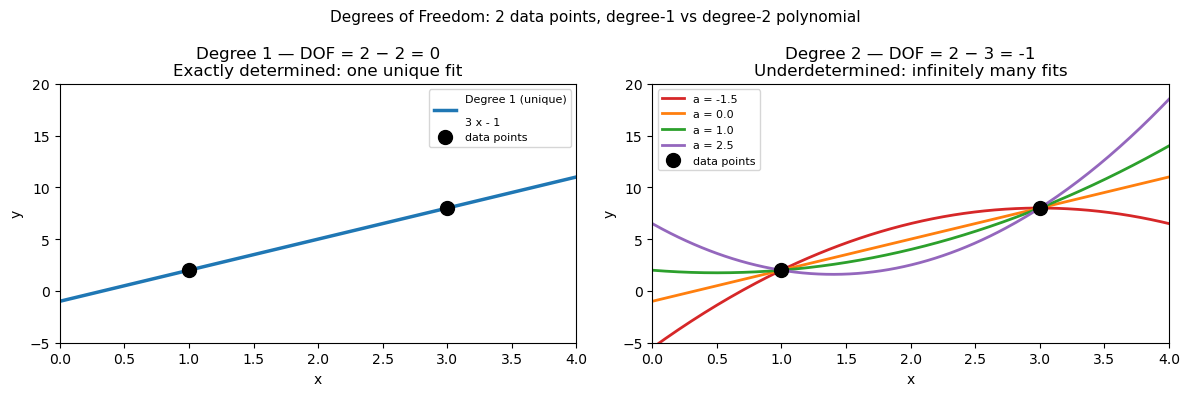

Degree 1 (DOF = 0):
  Unique coefficients: [ 3. -1.]

Degree 2 (DOF = -1) — all four pass exactly through the same two points:
  a=-1.5 → coeffs = [-1.5  9.  -5.5]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+0.0 → coeffs = [ 0.  3. -1.]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+1.0 → coeffs = [ 1. -1.  2.]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+2.5 → coeffs = [ 2.5 -7.   6.5]  | check: p(1.0)=2.0, p(3.0)=8.0


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Two data points
x_pts = np.array([1.0, 3.0])
y_pts = np.array([2.0, 8.0])

x_fine = np.linspace(0, 4, 200)

# ── Degree 1: DOF = 2 - 2 = 0  (unique solution) ─────────────────────────────
c1 = np.polyfit(x_pts, y_pts, 1)       # one unique line
y1 = np.polyval(c1, x_fine)

# ── Degree 2: DOF = 2 - 3 = -1 (underdetermined — infinitely many solutions) ─
# np.polyfit returns ONE solution (minimum-norm), but infinitely many exist.
# We generate three more by varying the free parameter 'a' manually.
#   y = a*x^2 + bx + c  — with 2 equations and 3 unknowns,
#   'a' is free. Fix a, then solve for b and c.
def quadratic_through_two_points(x_pts, y_pts, a):
    """Given 'a', find b,c so that ax^2 + bx + c passes through both points."""
    x1, x2 = x_pts
    y1, y2 = y_pts
    # y1 = a*x1^2 + b*x1 + c  →  b*x1 + c = y1 - a*x1^2
    # y2 = a*x2^2 + b*x2 + c  →  b*x2 + c = y2 - a*x2^2
    A = np.array([[x1, 1], [x2, 1]])
    rhs = np.array([y1 - a*x1**2, y2 - a*x2**2])
    b, c = np.linalg.solve(A, rhs)
    return np.array([a, b, c])

a_values = [-1.5, 0.0, 1.0, 2.5]   # four choices of the free parameter
colors_q  = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: degree 1 (unique)
ax = axes[0]
ax.plot(x_fine, y1, 'tab:blue', linewidth=2.5, label=f'Degree 1 (unique)\n{np.poly1d(c1)}')
ax.plot(x_pts, y_pts, 'ko', markersize=10, zorder=5, label='data points')
ax.set_title(f'Degree 1 — DOF = {len(x_pts)} − 2 = {len(x_pts)-2}\nExactly determined: one unique fit')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 4); ax.set_ylim(-5, 20)
ax.legend(fontsize=8)

# Right: degree 2 (infinitely many)
ax = axes[1]
for a_val, col in zip(a_values, colors_q):
    coeffs_q = quadratic_through_two_points(x_pts, y_pts, a_val)
    ax.plot(x_fine, np.polyval(coeffs_q, x_fine), color=col,
            linewidth=2, label=f'a = {a_val}')
ax.plot(x_pts, y_pts, 'ko', markersize=10, zorder=5, label='data points')
ax.set_title(f'Degree 2 — DOF = {len(x_pts)} − 3 = {len(x_pts)-3}\nUnderdetermined: infinitely many fits')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 4); ax.set_ylim(-5, 20)
ax.legend(fontsize=8)

plt.suptitle('Degrees of Freedom: 2 data points, degree-1 vs degree-2 polynomial', fontsize=11)
plt.tight_layout()
plt.show()

print("Degree 1 (DOF = 0):")
print(f"  Unique coefficients: {c1.round(4)}")
print()
print("Degree 2 (DOF = -1) — all four pass exactly through the same two points:")
for a_val in a_values:
    c = quadratic_through_two_points(x_pts, y_pts, a_val)
    print(f"  a={a_val:+.1f} → coeffs = {c.round(4)}  | check: p({x_pts[0]})={np.polyval(c, x_pts[0]):.1f}, p({x_pts[1]})={np.polyval(c, x_pts[1]):.1f}")


(12.3.5)=
### 12.3.5 Overfitting: When Higher Degree Hurts

Adding more polynomial terms always reduces training error, but can create **overfitting**: the polynomial wiggles between data points and performs poorly outside the training range.

**Why does adding terms always reduce training error?**
With $N$ data points and a degree-$(N-1)$ polynomial, you have exactly enough free coefficients to pass through every point perfectly — residuals become zero by construction. But this is not a good model; it has memorized the noise in the data rather than learned the underlying trend.

**Degrees of freedom** = number of adjustable parameters (coefficients) available to fit the data. A degree-$n$ polynomial has $n+1$ coefficients, so $n+1$ degrees of freedom.

| Degree | Degrees of freedom | Behavior |
|--------|--------------------|----------|
| High ($N-1$) | $N$ — one per data point | Zero training error · High variance · Overfitting risk |
| Low–moderate | $\ll N$ | Nonzero residual · Better generalization · Controlled flexibility |

**The bias-variance tradeoff:**
- A low-degree polynomial is *too rigid* — it misses real structure in the data
- A high-degree polynomial is *too flexible* — it chases every fluctuation and noise spike

> Bias = systematic error from the model being too simple to capture the true shape of the data.
> Variance = sensitivity to the specific data points you happened to measure.

The right degree sits in between: flexible enough to capture the physical trend, not so flexible that it fits the noise. A practical warning sign: if the polynomial behaves wildly *between* data points or shoots off just outside the data range, the degree is too high.

$$
\text{If } \deg(p) = N - 1 \text{ and you have } N \text{ points} \implies \text{SS}_{\text{res}} = 0,\quad R^2 = 1 \quad \text{(but the model is useless)}
$$

Here we deliberately use degree 9 (with only 10 data points) to illustrate the problem.

> ### 📋 Instructor Note — 12.3.5 (Overfitting)
> 
> EXPLAIN THIS WITH DRAWING!! - 2 points, 3 points examples!
>
> Important warning before we move on. More polynomial terms *always* reduces training error. That does not mean the model is better.
> 
> *(Run the wiggly-data plot cell — degree 2, 5, 9)*
> 
> Degree 2 underfits — it misses the oscillations entirely. Degree 5 is appropriate — captures the structure, residuals look random. Degree 9 starts overfitting — chasing noise.
> 
> *(Run the Cp overfitting cell — degree 3 vs degree 9)*
> 
> With 10 data points and a degree-9 polynomial, R² = 1.000 — perfect fit. But look at what happens between the data points and especially outside the training range: **wild oscillations**. The model has memorized the data rather than learned the underlying trend.
> 
> For smooth physical properties like $C_p$, degree 2–4 is almost always the right choice. Use MAE, R², and visual residual inspection to pick the degree — not just minimum training error.

Degree         MAE        R²  Note
------------------------------------------------
     2      0.6030    0.1219  underfit — misses oscillations
     5      0.2763    0.7914  good fit — captures structure
     9      0.1583    0.9236  starts to overfit noise


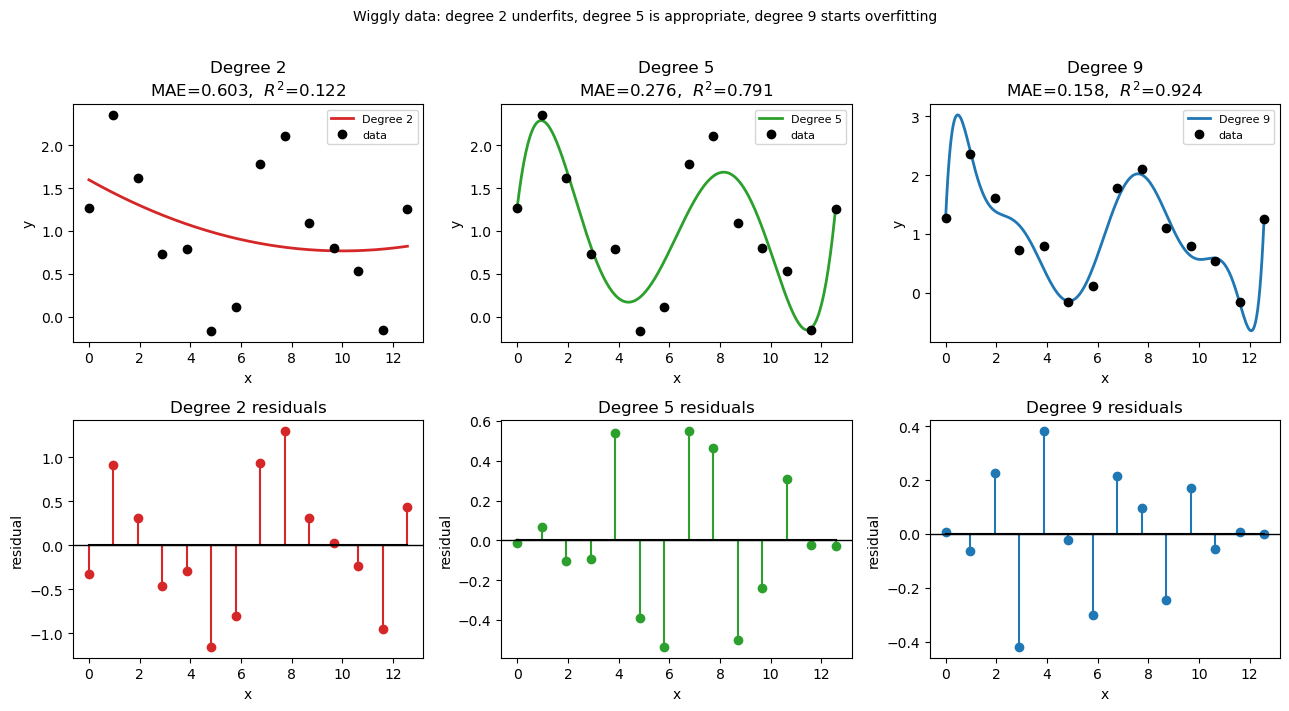

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ── Wiggly dataset: a signal with genuine oscillations + small noise ──────────
# Imagine a periodic reaction yield measured across 12 experimental conditions.
np.random.seed(3)
x_wig = np.linspace(0, 4 * np.pi, 14)
y_wig = np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + np.random.normal(1, 0.15, 14) # np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + 


x_fine = np.linspace(0, 4 * np.pi, 300)

# Fit with degree 2, 5, and 9
degs   = [2, 5, 9]
colors = ['tab:red', 'tab:green', 'tab:blue']
fits_w = {d: np.polyfit(x_wig, y_wig, d) for d in degs}

# ── Metrics ───────────────────────────────────────────────────────────────────
SS_tot_w = np.sum((y_wig - np.mean(y_wig))**2)
print(f"{'Degree':>6}  {'MAE':>10}  {'R²':>8}  {'Note'}")
print("-" * 48)
notes = {2: 'underfit — misses oscillations',
         5: 'good fit — captures structure',
         9: 'starts to overfit noise'}
for d in degs:
    pred = np.polyval(fits_w[d], x_wig)
    res  = y_wig - pred
    mae  = np.mean(np.abs(res))
    r2   = 1 - np.sum(res**2) / SS_tot_w
    print(f"{d:>6}  {mae:>10.4f}  {r2:>8.4f}  {notes[d]}")

# ── Plot: fits ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, (d, color) in enumerate(zip(degs, colors)):
    y_pred_fine = np.polyval(fits_w[d], x_fine)
    y_pred_data = np.polyval(fits_w[d], x_wig)
    residuals   = y_wig - y_pred_data
    mae  = np.mean(np.abs(residuals))
    r2   = 1 - np.sum(residuals**2) / SS_tot_w

    # Top row: fit vs data
    ax = axes[0, col]
    ax.plot(x_fine, y_pred_fine, color=color, linewidth=2, label=f'Degree {d}')
    ax.plot(x_wig, y_wig, 'ko', markersize=6, zorder=5, label='data')
    ax.set_title(f'Degree {d}\nMAE={mae:.3f},  $R^2$={r2:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

    # Bottom row: residuals
    ax = axes[1, col]
    ax.stem(x_wig, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_title(f'Degree {d} residuals')
    ax.set_xlabel('x'); ax.set_ylabel('residual')

plt.suptitle('Wiggly data: degree 2 underfits, degree 5 is appropriate, degree 9 starts overfitting',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

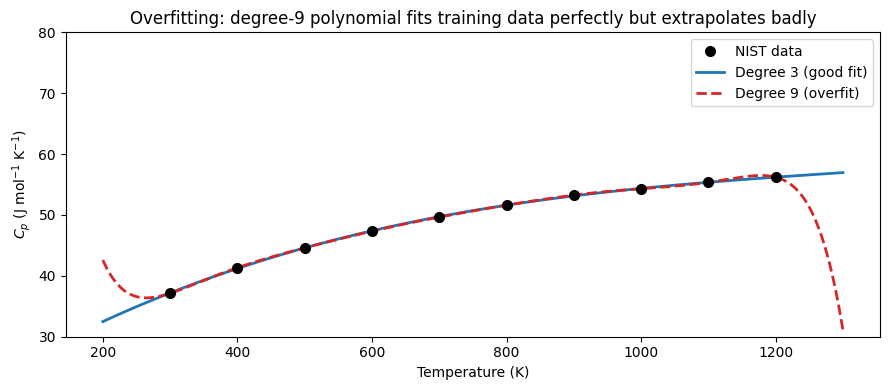

Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.
Use R² and visual inspection — not just training error — to choose degree.


In [ ]:
# ── Overfitting demonstration ─────────────────────────────────────────────────
coeffs_deg3 = np.polyfit(T_data, Cp_data, 3)
coeffs_deg9 = np.polyfit(T_data, Cp_data, 9)

T_ext = np.linspace(200, 1300, 400)   # extend beyond the data range

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
ax.plot(T_ext, np.polyval(coeffs_deg3, T_ext),
        'tab:blue', linewidth=2, label='Degree 3 (good fit)')
ax.plot(T_ext, np.polyval(coeffs_deg9, T_ext),
        'tab:red',  linewidth=2, linestyle='--', label='Degree 9 (overfit)')
ax.set_ylim(30, 80)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title('Overfitting: degree-9 polynomial fits training data perfectly but extrapolates badly')
ax.legend()
plt.tight_layout()
plt.show()

print("Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.")
print("Use R² and visual inspection — not just training error — to choose degree.")

(12.3.6)=
### 12.3.6 Using the Fit: Integrating $C_p$ Analytically

With the degree-3 fit in hand, we integrate $C_p(T)$ to compute the enthalpy change:

$$
\Delta H = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

`np.poly1d` exposes a `.integ()` method that returns the antiderivative polynomial.

> ### 📋 Instructor Note — 12.3.6
> 
> Now back to the original problem. With the degree-3 fit in hand, `.integ()` gives the antiderivative polynomial instantly:
> 
> *(Run the integration cell)*
> 
> ```
> Degree-3 Cp polynomial:
> 1.119e-08 x³ - 4.498e-05 x² + 0.06745 x + 20.71
> 
> ΔH = 24067.83 J/mol = 24.07 kJ/mol
> ```
> 
> That's the enthalpy required to heat 1 mole of CO₂ from 400 K to 900 K — a number you plug directly into an energy balance. The whole workflow: `polyfit` → `poly1d` → `.integ()` → evaluate the definite integral.

In [13]:
# ── Integrate Cp from T1 to T2 using the degree-3 fit ────────────────────────
p3 = np.poly1d(np.polyfit(T_data, Cp_data, 3))
P3 = p3.integ()            # antiderivative (integration constant = 0)

T1, T2 = 400.0, 900.0      # K
dH = P3(T2) - P3(T1)       # J/mol

print("Degree-3 Cp polynomial fit:")
print(p3)
print(f"\nIntegral of Cp from {T1:.0f} K to {T2:.0f} K:")
print(f"  Delta_H = {dH:.2f} J/mol  =  {dH/1000:.4f} kJ/mol")

Degree-3 Cp polynomial fit:
           3             2
1.119e-08 x - 4.498e-05 x + 0.06745 x + 20.71

Integral of Cp from 400 K to 900 K:
  Delta_H = 24067.83 J/mol  =  24.0678 kJ/mol


(12.4)=
## 12.4 Summary

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Polynomial evaluation** | `np.polyval(coeffs, x)` | Evaluate a stored coefficient array at $x$ |
| **Polynomial object** | `np.poly1d(coeffs)` | Callable; `.integ()` returns antiderivative |
| **Least-squares fit** | `np.polyfit(x, y, deg)` | Fit noisy or tabulated data; keep degree small |
| **Residuals** | $e_i = y_i - p(x_i)$ | Signed error at each data point |
| **MAE** | $\frac{1}{N}\sum\|e_i\|$ | Average error in original units; easy to interpret |
| **MSE** | $\frac{1}{N}\sum e_i^2$ | Penalizes large errors; units are $y^2$ |
| **$R^2$** | $1 - \sum e_i^2 / \sum(y_i-\bar{y})^2$ | Fraction of variance explained; 1 = perfect |